# 03 Demand Estimation

## Business Question

How sensitive is vehicle demand to price after controlling for product attributes, brand positioning, market differences, and time effects?

This section estimates log-log demand models where the price coefficient can be interpreted as price elasticity.

In [3]:
print(f"Observations: {cars.shape[0]:,}")
print(f"Variables: {cars.shape[1]}")

Observations: 11,431
Variables: 54


In [4]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

cars = pd.read_csv("../data/cars.csv", encoding="latin1")
cars.columns = cars.columns.str.strip()

cars_model = cars.dropna(subset=["qu", "eurpr", "hp", "we", "li", "avgurprrival", "nco", "engdpc"]).copy()

cars_model["log_qu"] = np.log(cars_model["qu"])
cars_model["log_price"] = np.log(cars_model["eurpr"])
cars_model["log_income"] = np.log(cars_model["engdpc"])

model = smf.ols(
    "log_qu ~ log_price + hp + we + li + avgurprrival + nco + log_income + C(brand) + C(cla) + C(ma) + C(ye)",
    data=cars_model
).fit(cov_type="HC3")

In [6]:

key_results = pd.DataFrame({
    "Variable": ["log_price", "hp", "we", "li", "avgurprrival", "nco", "log_income"],
    "Coefficient": [model.params.get(v) for v in ["log_price", "hp", "we", "li", "avgurprrival", "nco", "log_income"]],
    "P-value": [model.pvalues.get(v) for v in ["log_price", "hp", "we", "li", "avgurprrival", "nco", "log_income"]]
})

key_results

,Variable,Coefficient,P-value
0,log_price,-1.374005,4.867808e-30
1,hp,-0.017979,1.475541e-26
2,we,0.001621,6.932413e-17
3,li,-0.093385,1.071529e-11
4,avgurprrival,0.000158,2.391557e-11
5,nco,0.000735,7.697971e-01
6,log_income,0.437528,1.848439e-02


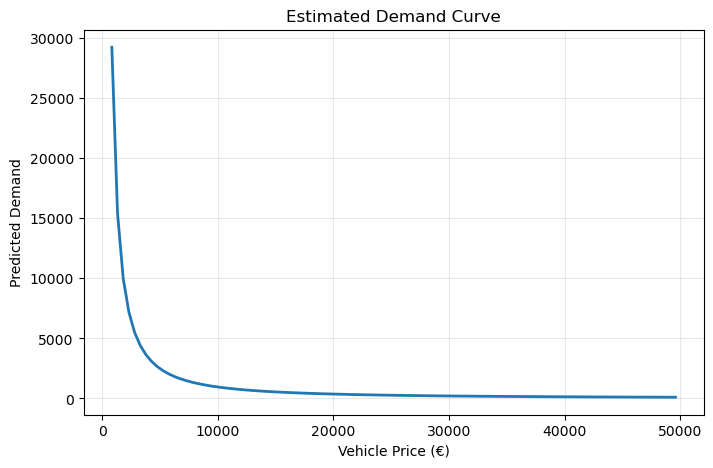

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Price range
price_grid = np.linspace(
    cars_model["eurpr"].min(),
    cars_model["eurpr"].max(),
    100
)

# Average values for other variables
avg_hp = cars_model["hp"].mean()
avg_we = cars_model["we"].mean()
avg_li = cars_model["li"].mean()
avg_rival = cars_model["avgurprrival"].mean()
avg_nco = cars_model["nco"].mean()
avg_income = cars_model["log_income"].mean()

# Use the most common category for fixed effects
ref_brand = cars_model["brand"].mode()[0]
ref_cla = cars_model["cla"].mode()[0]
ref_ma = cars_model["ma"].mode()[0]
ref_ye = cars_model["ye"].mode()[0]

pred_df = pd.DataFrame({
    "log_price": np.log(price_grid),
    "hp": avg_hp,
    "we": avg_we,
    "li": avg_li,
    "avgurprrival": avg_rival,
    "nco": avg_nco,
    "log_income": avg_income,
    "brand": ref_brand,
    "cla": ref_cla,
    "ma": ref_ma,
    "ye": ref_ye
})

pred_log_q = model.predict(pred_df)

pred_q = np.exp(pred_log_q)

plt.figure(figsize=(8,5))

plt.plot(price_grid, pred_q, linewidth=2)

plt.title("Estimated Demand Curve")
plt.xlabel("Vehicle Price (€)")
plt.ylabel("Predicted Demand")
plt.grid(alpha=0.3)

plt.show()

### Business Interpretation

The estimated demand curve slopes downward, indicating that higher prices are associated with lower expected demand after controlling for product characteristics, competitive conditions, and market effects.

The relatively steep decline supports the estimated price elasticity greater than one in absolute value, suggesting that demand is price-sensitive.

### Key Findings

• Demand is negatively associated with vehicle prices.

• Competitor pricing also influences demand, indicating substitution effects.

• Product attributes and market characteristics explain substantial variation in vehicle sales beyond price alone.

• Controlling for brand, category, market, and year improves the credibility of the estimated price elasticity.

### Managerial Recommendation

The estimated elasticity suggests that broad price increases are unlikely to maximize revenue across all products.

Instead, pricing decisions should be differentiated by vehicle segment, brand positioning, and competitive intensity.